# 05 — Валидация сегментационной модели

Загружаем обученный `TopologyAdaptiveRoutedUNet3D` и прогоняем на всей val-выборке.
Цель: получить объективную статистику качества — Dice, BCE loss, voxel error rate —
с разбивкой по породе (Berea / BanderaBrown) и размеру куба (64 / 128 / 192).

In [1]:
from pathlib import Path
from itertools import islice
import importlib
import sys
import time
import warnings

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "utils").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Project root with src/utils was not found")

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import utils.data as data_module
import utils.adaptive_routing as adaptive_module
import utils.losses as losses_module

data_module = importlib.reload(data_module)
adaptive_module = importlib.reload(adaptive_module)
losses_module = importlib.reload(losses_module)

DEFAULT_CUBE_SIZES = data_module.DEFAULT_CUBE_SIZES
BereaPatchDataset = data_module.BereaPatchDataset
CubeSizeBatchSampler = data_module.CubeSizeBatchSampler
TopologyAdaptiveRoutedUNet3D = adaptive_module.TopologyAdaptiveRoutedUNet3D
dice_score_from_logits = losses_module.dice_score_from_logits

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_DIR = ROOT / "models"
print("ROOT:", ROOT, "device:", device)

ROOT: f:\PycharmProjects\micro_ct device: cuda


## 1. Параметры валидации

In [2]:
CHECKPOINT_PATH = MODEL_DIR / "segmentation_best.pth"
CUBE_SIZES = [64, 128]  # smoke validation; use [64, 128] or list(DEFAULT_CUBE_SIZES) for fuller checks
BATCH_SIZE_BY_CUBE_SIZE = {64: 16, 128: 2, 192: 1}
VAL_SAMPLES_PER_GROUP = 16  # per rock + cube_size; None = all validation samples
NUM_WORKERS = 0
PIN_MEMORY = device == "cuda"
USE_RAM_CACHE = True  # cache selected validation cubes after first CPU read

# Сколько val-батчей максимум (None = все). Быстрая оценка: первые 50.
MAX_VAL_BATCHES = 8  # additional hard cap; None = use all sampled validation batches
POSTFIX_EVERY = 50

print("Checkpoint:", CHECKPOINT_PATH)
print("Cube sizes:", CUBE_SIZES)
print("Device:", device)
print("RAM cache:", USE_RAM_CACHE)

Checkpoint: f:\PycharmProjects\micro_ct\models\segmentation_best.pth
Cube sizes: [64, 128]
Device: cuda
RAM cache: True


## 2. Загрузка модели

In [3]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
base_channels = int(checkpoint.get("base_channels", 16))
ctx_dim = int(checkpoint.get("ctx_dim", 64))
ph_dim = int(checkpoint.get("ph_dim", 6))
print(f"Loaded checkpoint: base_channels={base_channels}, ctx_dim={ctx_dim}, ph_dim={ph_dim}")
print(f"Best val_loss={checkpoint['val_loss']:.4f}, val_dice={checkpoint['val_dice']:.4f} at epoch={checkpoint['epoch']}")

model = TopologyAdaptiveRoutedUNet3D(
    in_channels=1,
    out_channels=1,
    base_channels=base_channels,
    ctx_dim=ctx_dim,
    ph_dim=ph_dim,
    topology_dim=ph_dim,
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loaded checkpoint: base_channels=16, ctx_dim=64, ph_dim=6
Best val_loss=0.1128, val_dice=0.9293 at epoch=10
Model parameters: 1,445,714


## 3. Загрузка val-датасета

Берём все породы (Berea, BanderaBrown) и все размеры кубов (64, 128, 192).
На валидации — без шума (noise_types=["none"]), без балансировки.

In [4]:
val_ds = BereaPatchDataset(
    ROOT,
    split="val",
    cube_size=CUBE_SIZES,
    use_raw_gray=False,
    noise_types=["none"],
    balance=False,
    samples_per_group=VAL_SAMPLES_PER_GROUP,
    return_aux_targets=False,
    return_topology=True,
)

class CachedPatchDataset:
    def __init__(self, dataset):
        self.samples = []
        start = time.perf_counter()
        for idx in tqdm(range(len(dataset)), desc="Caching val cubes", leave=False):
            sample = dataset[idx]
            self.samples.append({
                "x": sample["x"].contiguous(),
                "y": sample["y"].contiguous(),
                "coord": sample["coord"],
                "rock": sample["rock"],
                "cube_size": sample["cube_size"],
                "porosity": sample["porosity"],
                "percolates": sample["percolates"],
                "noise": sample["noise"],
                "ph_features": sample["ph_features"].contiguous(),
                "topology_target": sample["topology_target"].contiguous(),
            })
        self.df = dataset.df.iloc[dataset.sample_index].reset_index(drop=True)
        self.sample_index = np.arange(len(self.samples))
        self.cube_sizes = dataset.cube_sizes
        elapsed = time.perf_counter() - start
        cached_bytes = sum(
            sample["x"].numel() * sample["x"].element_size()
            + sample["y"].numel() * sample["y"].element_size()
            for sample in self.samples
        )
        print(f"Cached {len(self.samples)} cubes in RAM: {cached_bytes / 1024**2:.1f} MB, {elapsed:.1f}s")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[int(idx)]

if USE_RAM_CACHE:
    val_ds = CachedPatchDataset(val_ds)

val_sampler = CubeSizeBatchSampler(
    val_ds,
    BATCH_SIZE_BY_CUBE_SIZE,
    shuffle=False,
)
val_loader = DataLoader(
    val_ds,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Val dataset: {len(val_ds)} samples, {len(val_loader)} batches")
print("Samples per rock+cube_size:", VAL_SAMPLES_PER_GROUP)
print("Batch sizes by cube_size:", BATCH_SIZE_BY_CUBE_SIZE)
print()
print("Распределение по группам в index-файлах:")
display(val_ds.df.groupby(["rock", "cube_size"]).size().rename("count").reset_index())
print("\nФактически выбранные samples после VAL_SAMPLES_PER_GROUP:")
effective_val = val_ds.df.iloc[val_ds.sample_index]
display(effective_val.groupby(["rock", "cube_size"]).size().rename("count").reset_index())
print("\nBatches by cube_size:")
for size, indices in val_sampler.indices_by_size.items():
    bs = val_sampler._batch_size_for(size)
    print(f"  {size}: samples={len(indices)}, batch_size={bs}, batches={len(range(0, len(indices), bs))}")

Caching val cubes:   0%|          | 0/64 [00:00<?, ?it/s]

Cached 64 cubes in RAM: 576.0 MB, 153.9s
Val dataset: 64 samples, 18 batches
Samples per rock+cube_size: 16
Batch sizes by cube_size: {64: 16, 128: 2, 192: 1}

Распределение по группам в index-файлах:


,rock,cube_size,count
0,BanderaBrown,64,16
1,BanderaBrown,128,16
2,Berea,64,16
3,Berea,128,16



Фактически выбранные samples после VAL_SAMPLES_PER_GROUP:


,rock,cube_size,count
0,BanderaBrown,64,16
1,BanderaBrown,128,16
2,Berea,64,16
3,Berea,128,16



Batches by cube_size:
  64: samples=32, batch_size=16, batches=2
  128: samples=32, batch_size=2, batches=16


## 4. Инференс на val-выборке

Собираем для каждого куба:
- Dice score
- BCE loss
- Voxel error rate (доля несовпадающих вокселей)
- Порода, размер, координаты, пористость

In [5]:
results = []  # список словарей
bce_loss_fn = torch.nn.BCEWithLogitsLoss(reduction="none")
load_times = []
forward_times = []

total_batches = len(val_loader) if MAX_VAL_BATCHES is None else min(len(val_loader), MAX_VAL_BATCHES)
val_iter = val_loader if MAX_VAL_BATCHES is None else islice(val_loader, MAX_VAL_BATCHES)
val_bar = tqdm(val_iter, total=total_batches, desc="Validation")
prev_batch_done = time.perf_counter()

with torch.inference_mode():
    for batch_idx, batch in enumerate(val_bar):
        batch_ready = time.perf_counter()
        load_times.append(batch_ready - prev_batch_done)

        x = batch["x"].to(device, non_blocking=PIN_MEMORY)
        y = batch["y"].to(device, non_blocking=PIN_MEMORY)
        ph_features = batch.get("ph_features")
        if ph_features is not None:
            ph_features = ph_features.to(device, non_blocking=PIN_MEMORY)
        if device == "cuda":
            torch.cuda.synchronize()
        forward_start = time.perf_counter()

        out = model(x, ph_features=ph_features, return_dict=True)
        logits = out["logits"]

        prob = torch.sigmoid(logits)
        pred_mask = (prob >= 0.5).float()
        flat_pred = pred_mask.flatten(1)
        flat_y = y.flatten(1)
        intersection = (flat_pred * flat_y).sum(dim=1)
        denom = flat_pred.sum(dim=1) + flat_y.sum(dim=1)
        dice_values = ((2.0 * intersection + 1e-6) / (denom + 1e-6)).detach().cpu().tolist()
        bce_values = bce_loss_fn(logits, y).flatten(1).mean(dim=1).detach().cpu().tolist()
        error_values = (pred_mask != y).float().flatten(1).mean(dim=1).detach().cpu().tolist()
        if device == "cuda":
            torch.cuda.synchronize()
        forward_times.append(time.perf_counter() - forward_start)

        rocks = list(batch["rock"]) if isinstance(batch["rock"], (list, tuple)) else [str(batch["rock"])] * x.size(0)
        cube_sizes = batch["cube_size"].detach().cpu().tolist()
        coords = batch["coord"].detach().cpu().tolist()
        porosities = y.flatten(1).mean(dim=1).detach().cpu().tolist()

        for i in range(x.size(0)):
            results.append({
                "rock": rocks[i],
                "cube_size": int(cube_sizes[i]),
                "coord": tuple(coords[i]),
                "porosity": float(porosities[i]),
                "dice": float(dice_values[i]),
                "bce_loss": float(bce_values[i]),
                "error_rate": float(error_values[i]),
            })

        # Сохраняем данные для визуализации худшего/лучшего
        if batch_idx == 0:
            first_x = x.detach().cpu()
            first_y = y.detach().cpu()
            first_logits = logits.detach().cpu()

        if batch_idx % POSTFIX_EVERY == 0:
            val_bar.set_postfix({
                "dice": f"{np.mean(dice_values):.4f}",
                "error": f"{np.mean(error_values):.4f}",
                "load_s": f"{np.mean(load_times[-10:]):.3f}",
                "gpu_s": f"{np.mean(forward_times[-10:]):.3f}",
            })
        prev_batch_done = time.perf_counter()

df = pd.DataFrame(results)
print(f"\nОбработано {len(df)} кубов")
if load_times and forward_times:
    print(f"Среднее ожидание batch: {np.mean(load_times):.3f}s")
    print(f"Средний forward+metrics: {np.mean(forward_times):.3f}s")
print(f"Средний Dice: {df['dice'].mean():.4f} ± {df['dice'].std():.4f}")
print(f"Средняя ошибка: {df['error_rate'].mean():.4f} ± {df['error_rate'].std():.4f}")

Validation:   0%|          | 0/8 [00:00<?, ?it/s]


Обработано 44 кубов
Среднее ожидание batch: 0.017s
Средний forward+metrics: 0.392s
Средний Dice: 0.9266 ± 0.0791
Средняя ошибка: 0.0300 ± 0.0270


## 5. Статистика по группам

In [6]:
print("=" * 60)
print("СТАТИСТИКА ПО ПОРОДАМ")
print("=" * 60)
rock_stats = df.groupby("rock")["dice"].agg(["mean", "std", "min", "max", "count"])
display(rock_stats.round(4))

print()
print("=" * 60)
print("СТАТИСТИКА ПО РАЗМЕРУ КУБА")
print("=" * 60)
size_stats = df.groupby("cube_size")["dice"].agg(["mean", "std", "min", "max", "count"])
display(size_stats.round(4))

print()
print("=" * 60)
print("СТАТИСТИКА ПО ПОРОДЕ × РАЗМЕР")
print("=" * 60)
cross_stats = df.groupby(["rock", "cube_size"])["dice"].agg(["mean", "std", "min", "max", "count"])
display(cross_stats.round(4))

СТАТИСТИКА ПО ПОРОДАМ


,mean,std,min,max,count
rock,,,,,
BanderaBrown,0.9539,0.0194,0.8855,0.9721,28
Berea,0.8787,0.1158,0.5647,0.9760,16



СТАТИСТИКА ПО РАЗМЕРУ КУБА


,mean,std,min,max,count
cube_size,,,,,
64,0.9137,0.0894,0.5647,0.9760,32
128,0.9608,0.0144,0.9262,0.9721,12



СТАТИСТИКА ПО ПОРОДЕ × РАЗМЕР


mean     std     min     max  count
rock         cube_size                                       
BanderaBrown 64         0.9488  0.0214  0.8855  0.9709     16
             128        0.9608  0.0144  0.9262  0.9721     12
Berea        64         0.8787  0.1158  0.5647  0.9760     16

## 6. Графики

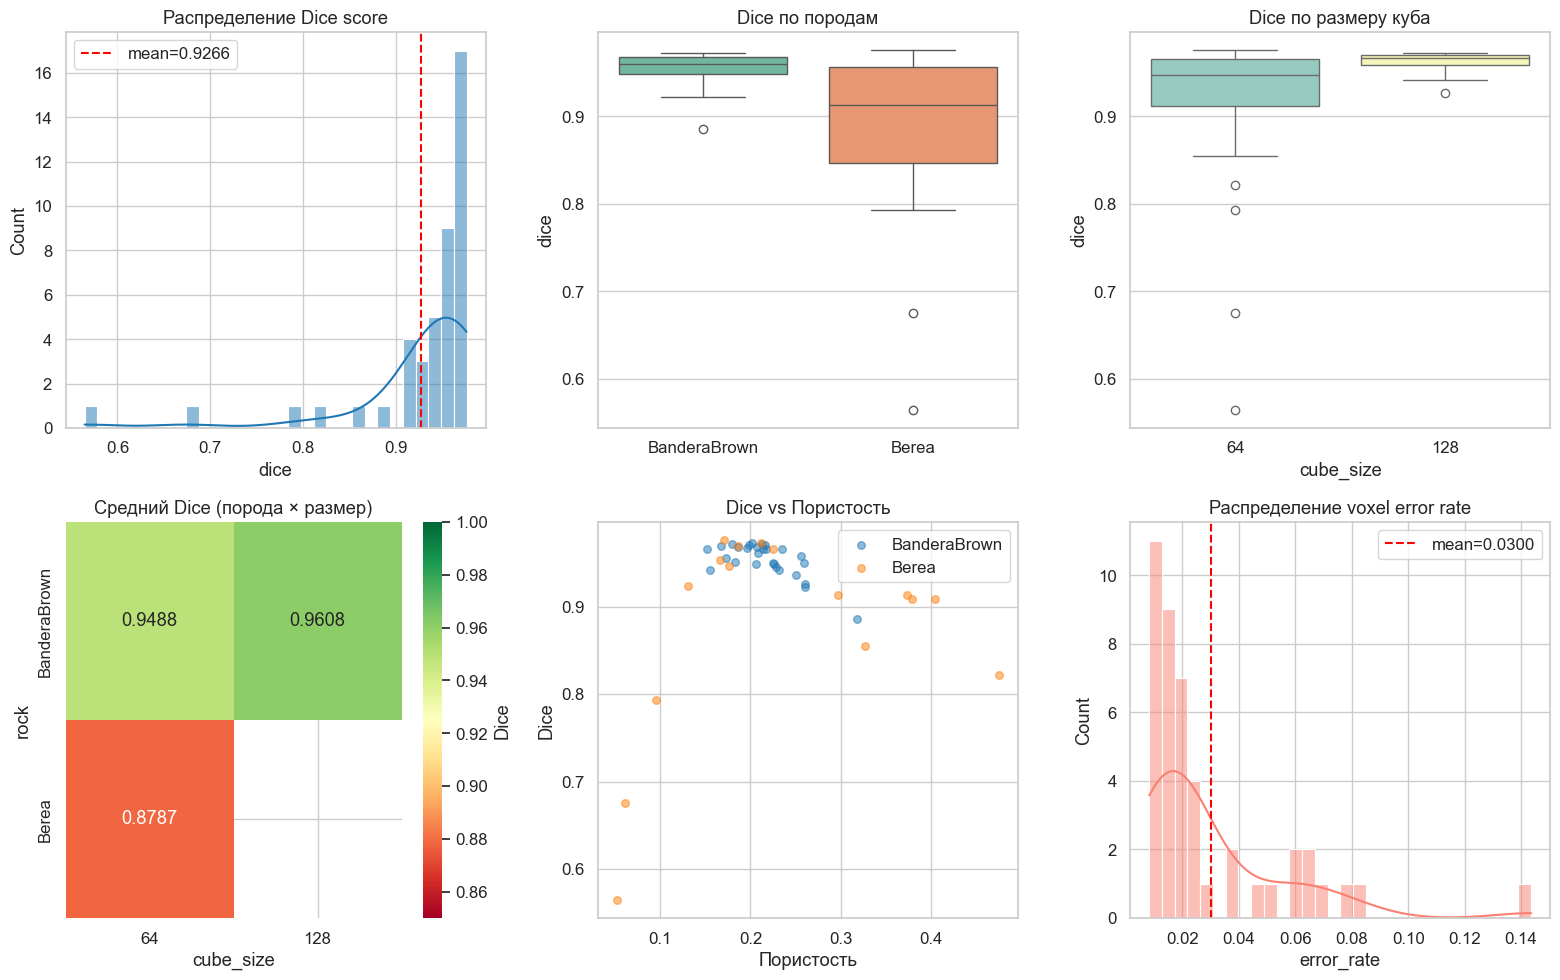

In [7]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 6.1 Гистограмма Dice
ax = axes[0, 0]
sns.histplot(df, x="dice", bins=30, ax=ax, kde=True)
ax.axvline(df["dice"].mean(), color="red", linestyle="--", label=f"mean={df['dice'].mean():.4f}")
ax.set_title("Распределение Dice score")
ax.legend()

# 6.2 Box plot по породам
ax = axes[0, 1]
sns.boxplot(data=df, x="rock", y="dice", ax=ax, palette="Set2")
ax.set_title("Dice по породам")
ax.set_xlabel("")

# 6.3 Box plot по размеру куба
ax = axes[0, 2]
sns.boxplot(data=df, x="cube_size", y="dice", ax=ax, palette="Set3")
ax.set_title("Dice по размеру куба")

# 6.4 Heatmap порода × размер
ax = axes[1, 0]
pivot = df.pivot_table(values="dice", index="rock", columns="cube_size", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdYlGn", ax=ax, vmin=0.85, vmax=1.0,
            cbar_kws={"label": "Dice"})
ax.set_title("Средний Dice (порода × размер)")

# 6.5 Dice vs Porosity
ax = axes[1, 1]
for rock_name in df["rock"].unique():
    subset = df[df["rock"] == rock_name]
    ax.scatter(subset["porosity"], subset["dice"], alpha=0.5, label=rock_name, s=30)
ax.set_xlabel("Пористость")
ax.set_ylabel("Dice")
ax.set_title("Dice vs Пористость")
ax.legend()

# 6.6 Гистограмма error_rate
ax = axes[1, 2]
sns.histplot(df, x="error_rate", bins=30, ax=ax, kde=True, color="salmon")
ax.axvline(df["error_rate"].mean(), color="red", linestyle="--", label=f"mean={df['error_rate'].mean():.4f}")
ax.set_title("Распределение voxel error rate")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Худшие и лучшие кубы

Показывает координаты (origin z,y,x) — их можно открыть в визуализаторе.

In [8]:
TOP_K = 10

print("=" * 60)
print(f"ТОП-{TOP_K} ХУДШИХ КУБОВ (по Dice)")
print("=" * 60)
worst = df.nsmallest(TOP_K, "dice")
display(worst[["rock", "cube_size", "coord", "dice", "error_rate", "porosity"]].reset_index(drop=True))

print()
print("=" * 60)
print(f"ТОП-{TOP_K} ЛУЧШИХ КУБОВ (по Dice)")
print("=" * 60)
best = df.nlargest(TOP_K, "dice")
display(best[["rock", "cube_size", "coord", "dice", "error_rate", "porosity"]].reset_index(drop=True))

ТОП-10 ХУДШИХ КУБОВ (по Dice)


,rock,cube_size,coord,dice,error_rate,porosity
0,Berea,64,"(936, 512, 448)",0.564683,0.079765,0.052158
1,Berea,64,"(64, 832, 256)",0.674960,0.059010,0.061295
2,Berea,64,"(448, 0, 768)",0.793449,0.049839,0.095932
3,Berea,64,"(256, 192, 936)",0.822015,0.143597,0.475193
4,Berea,64,"(576, 896, 576)",0.855344,0.082642,0.326935
5,BanderaBrown,64,"(64, 512, 192)",0.885539,0.065266,0.317711
6,Berea,64,"(832, 448, 320)",0.908351,0.067944,0.404640
7,Berea,64,"(640, 640, 128)",0.908410,0.063572,0.378834
8,Berea,64,"(192, 896, 936)",0.912713,0.047668,0.296871
9,Berea,64,"(512, 704, 576)",0.913022,0.059689,0.372971



ТОП-10 ЛУЧШИХ КУБОВ (по Dice)


,rock,cube_size,coord,dice,error_rate,porosity
0,Berea,64,"(64, 512, 192)",0.975969,0.008232,0.170361
1,Berea,64,"(896, 896, 512)",0.972494,0.011532,0.211399
2,BanderaBrown,128,"(512, 256, 512)",0.972067,0.011285,0.201236
3,BanderaBrown,128,"(384, 0, 128)",0.971572,0.012070,0.212517
4,BanderaBrown,64,"(832, 448, 320)",0.970863,0.010403,0.179298
5,BanderaBrown,128,"(256, 768, 640)",0.970441,0.012549,0.215889
6,BanderaBrown,128,"(640, 256, 768)",0.969964,0.012013,0.198793
7,Berea,64,"(512, 384, 384)",0.969147,0.011745,0.185928
8,BanderaBrown,64,"(936, 512, 448)",0.968825,0.010635,0.167103
9,BanderaBrown,128,"(128, 0, 872)",0.968088,0.013089,0.207345


## 8. Визуализация примеров сегментации (слайсы)

Показываем для лучшего, среднего и худшего куба:
- Input (серый)
- Ground truth (бинарная маска пор)
- Предсказание (probability map)
- Ошибки: FP — красный, FN — синий

⚠️ Внимание: из-за особенностей Jupyter, перезапустите ячейку если графики не отображаются.
   Если размер куба большой (192³) — рендеринг может быть медленным.

In [9]:
# Быстро собираем данные для визуализации трех примеров из уже загруженного val_ds
examples = {}

def _coord_tuple(value):
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().tolist()
    elif isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, str):
        return tuple(int(part.strip()) for part in value.strip("()[]").split(",") if part.strip())
    return tuple(int(v) for v in value)

def _sample_key(sample):
    return (str(sample["rock"]), int(sample["cube_size"]), _coord_tuple(sample["coord"]))

sample_by_key = {}
for sample_idx in range(len(val_ds)):
    sample = val_ds[sample_idx]
    sample_by_key[_sample_key(sample)] = sample

picked_rows = [
    ("ХУДШИЙ", df.loc[df["dice"].idxmin()]),
    ("СРЕДНИЙ", df.loc[df["dice"].sub(df["dice"].median()).abs().idxmin()]),
    ("ЛУЧШИЙ", df.loc[df["dice"].idxmax()]),
]

pending = []
for label, row in picked_rows:
    key = (str(row["rock"]), int(row["cube_size"]), _coord_tuple(row["coord"]))
    sample = sample_by_key.get(key)
    if sample is None:
        print(f"Не удалось найти сэмпл {label} в текущем val_ds: {key}")
        continue
    pending.append((label, row, sample))

with torch.inference_mode():
    for cs in sorted({int(sample["cube_size"]) for _, _, sample in pending}):
        group = [(label, row, sample) for label, row, sample in pending if int(sample["cube_size"]) == cs]
        x_batch = torch.stack([sample["x"] for _, _, sample in group]).to(device, non_blocking=PIN_MEMORY)
        ph_batch = torch.stack([sample["ph_features"] for _, _, sample in group]).to(device, non_blocking=PIN_MEMORY)
        out = model(x_batch, ph_features=ph_batch, return_dict=True)
        probs = torch.sigmoid(out["logits"]).detach().cpu()

        for i, (label, row, sample) in enumerate(group):
            examples[label] = {
                "x": sample["x"][0].detach().cpu().numpy(),
                "y": sample["y"][0].detach().cpu().numpy(),
                "prob": probs[i, 0].numpy(),
                "dice": float(row["dice"]),
                "rock": str(row["rock"]),
                "cube_size": int(row["cube_size"]),
                "coord": _coord_tuple(row["coord"]),
            }

print(f"Загружено примеров: {len(examples)}")
for label, data in examples.items():
    print(f"  {label}: {data['rock']} {data['cube_size']}^3 coord={data['coord']} dice={data['dice']:.4f}")

Загружено примеров: 3
  ХУДШИЙ: Berea 64^3 coord=(936, 512, 448) dice=0.5647
  СРЕДНИЙ: BanderaBrown 64^3 coord=(832, 448, 512) dice=0.9494
  ЛУЧШИЙ: Berea 64^3 coord=(64, 512, 192) dice=0.9760


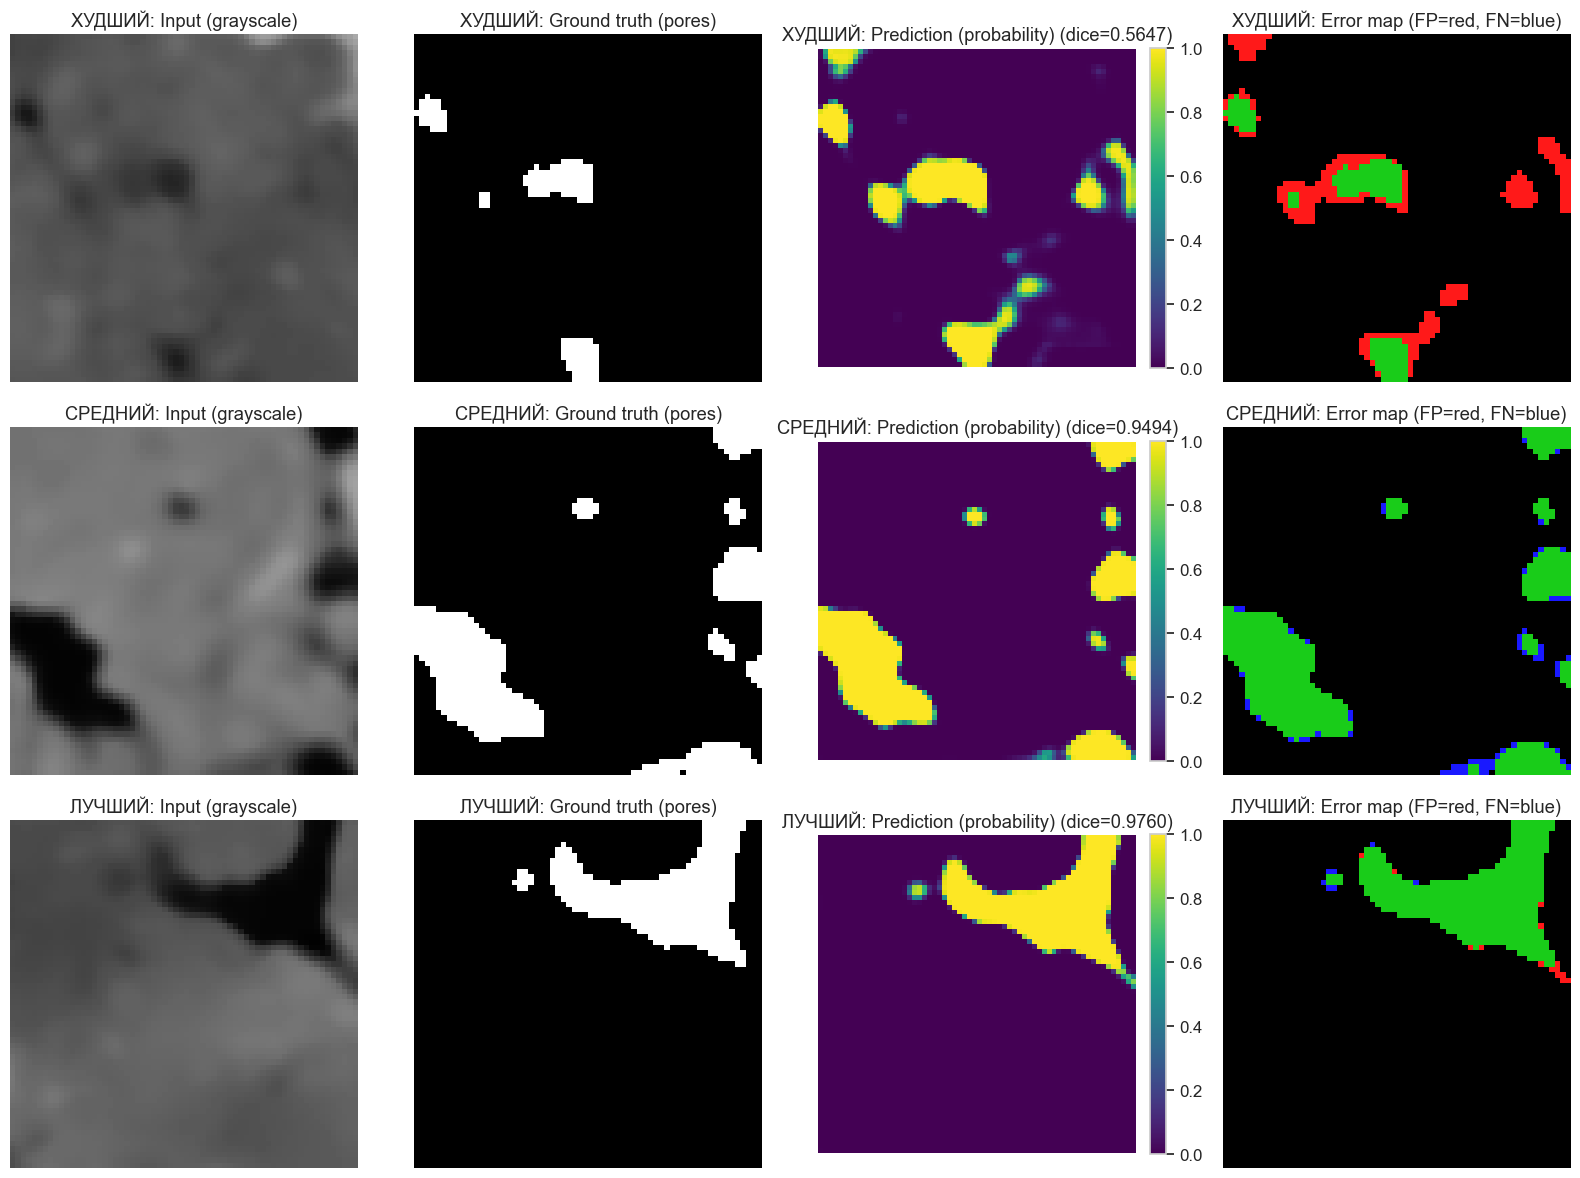

In [10]:
if len(examples) > 0:
    fig, axes = plt.subplots(len(examples), 4, figsize=(16, 4 * len(examples)))

    # Если пример один, axes будет одномерным — делаем двумерным
    if len(examples) == 1:
        axes = np.expand_dims(axes, axis=0)

    titles = [
        "Input (grayscale)",
        "Ground truth (pores)",
        "Prediction (probability)",
        "Error map (FP=red, FN=blue)"
    ]

    for row_idx, (label, data) in enumerate(examples.items()):
        x_np = data["x"]
        y_np = data["y"]
        prob = data["prob"]

        mid_z = x_np.shape[0] // 2

        input_slice = x_np[mid_z, :, :]
        gt_slice = y_np[mid_z, :, :]
        prob_slice = prob[mid_z, :, :]

        # ВАЖНО: приводим маски к boolean
        gt_mask = gt_slice >= 0.5
        pred_mask = prob_slice >= 0.5

        error_map = np.zeros((*gt_mask.shape, 3), dtype=np.float32)

        # FP: модель предсказала пору, а в GT её нет
        fp = pred_mask & (~gt_mask)
        error_map[fp] = [1.0, 0.1, 0.1]

        # FN: пора есть в GT, но модель её не предсказала
        fn = (~pred_mask) & gt_mask
        error_map[fn] = [0.1, 0.1, 1.0]

        # TP: правильно предсказанные поры
        tp = pred_mask & gt_mask
        error_map[tp] = [0.1, 0.8, 0.1]

        axes[row_idx, 0].imshow(input_slice, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, 0].set_title(f"{label}: {titles[0]}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, 1].set_title(f"{label}: {titles[1]}")
        axes[row_idx, 1].axis("off")

        im = axes[row_idx, 2].imshow(prob_slice, cmap="viridis", vmin=0, vmax=1)
        axes[row_idx, 2].set_title(f"{label}: {titles[2]} (dice={data['dice']:.4f})")
        axes[row_idx, 2].axis("off")
        plt.colorbar(im, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

        axes[row_idx, 3].imshow(error_map)
        axes[row_idx, 3].set_title(f"{label}: {titles[3]}")
        axes[row_idx, 3].axis("off")

    plt.tight_layout()
    plt.show()

## 9. Итоговая сводка

Вывод: на каких данных модель хороша, а где нужно дообучение.

In [11]:
print("=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)

overall_dice = df["dice"].mean()
print(f"Общий Dice: {overall_dice:.4f}")
print()

print("Dice по группам (порода × размер):")
pivot_summary = df.pivot_table(
    values="dice",
    index="rock",
    columns="cube_size",
    aggfunc=["mean", "std", "count"]
)
display(pivot_summary.round(4))

print()
print("Выводы:")
print()

# Анализ: на каких группах худший результат
group_means = df.groupby(["rock", "cube_size"])["dice"].mean()
worst_group = group_means.idxmin()
best_group = group_means.idxmax()

print(f"🔴 Самая сложная группа: {worst_group[0]} {worst_group[1]}³ (Dice={group_means.min():.4f})")
print(f"🟢 Самая лёгкая группа: {best_group[0]} {best_group[1]}³ (Dice={group_means.max():.4f})")

berea_dice = df[df["rock"] == "Berea"]["dice"].mean()
bandera_dice = df[df["rock"] == "BanderaBrown"]["dice"].mean()
print()
print(f"Berea: Dice = {berea_dice:.4f}")
print(f"BanderaBrown: Dice = {bandera_dice:.4f}")
print(f"Разница: {abs(berea_dice - bandera_dice):.4f}")

print()
print("Рекомендации:")
print("- Если разница между породами >0.02 → нужен лучший баланс данных")
print("- Если худшие кубы приходится на 192³ → увеличить долю 192³ в тренировке")
print("- Если все группы показывают Dice < 0.95 → проблема в архитектуре/гиперпараметрах")

ИТОГОВАЯ СВОДКА
Общий Dice: 0.9266

Dice по группам (порода × размер):


mean             std         count      
cube_size        64      128     64      128   64    128
rock                                                    
BanderaBrown  0.9488  0.9608  0.0214  0.0144  16.0  12.0
Berea         0.8787     NaN  0.1158     NaN  16.0   NaN


Выводы:

🔴 Самая сложная группа: Berea 64³ (Dice=0.8787)
🟢 Самая лёгкая группа: BanderaBrown 128³ (Dice=0.9608)

Berea: Dice = 0.8787
BanderaBrown: Dice = 0.9539
Разница: 0.0753

Рекомендации:
- Если разница между породами >0.02 → нужен лучший баланс данных
- Если худшие кубы приходится на 192³ → увеличить долю 192³ в тренировке
- Если все группы показывают Dice < 0.95 → проблема в архитектуре/гиперпараметрах


## 10. (Опционально) Экспорт результатов в CSV

Сохраняет таблицу с метриками каждого куба для дальнейшего анализа.

In [12]:
CSV_PATH = ROOT / "outputs" / "validation_results.csv"
df.to_csv(CSV_PATH, index=False)
print(f"Результаты сохранены: {CSV_PATH}")
display(df.head())

Результаты сохранены: f:\PycharmProjects\micro_ct\outputs\validation_results.csv


,rock,cube_size,coord,porosity,dice,bce_loss,error_rate
0,BanderaBrown,64,"(64, 832, 256)",0.250225,0.935456,0.084186,0.030415
1,BanderaBrown,64,"(512, 704, 576)",0.155586,0.941680,0.045169,0.019215
2,BanderaBrown,64,"(936, 512, 448)",0.167103,0.968825,0.024870,0.010635
3,BanderaBrown,64,"(512, 384, 384)",0.173313,0.954974,0.038558,0.016186
4,BanderaBrown,64,"(832, 448, 512)",0.224571,0.949400,0.056591,0.021667
